## ``EDA + Visualization + Pre-Processing - Video Games``

##### ``Sandra Ranilla-Cortina``

In [1]:
# Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.style.use('fivethirtyeight')
np.random.seed(777)

import warnings
warnings.filterwarnings("ignore", category = UserWarning)
warnings.filterwarnings("ignore", category = FutureWarning)

#### ``Exploratory Data Analysis (EDA)``

In [ ]:
# Video Games dataset
df_vg = pd.read_csv('https://raw.githubusercontent.com/sranillac/SRC_UniOvi/refs/heads/main/ML-IA/data/VideoGames/VideoGames-Dataset.csv', usecols = lambda column: column != 'Unnamed: 0')
df_vg.head(5)

,Game Title,User Rating,Age Group Targeted,Price,Platform,Requires Special Device,Developer,Publisher,Release Year,Genre,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,User Review Text,Game Mode,Min Number of Players
0,Grand Theft Auto V,36.4,All Ages,41.41,PC,No,Game Freak,Innersloth,2015,Adventure,No,55.3,Medium,Average,Poor,"Solid game, but too many bugs.",Offline,1
1,The Sims 4,38.3,Adults,57.56,PC,No,Nintendo,Electronic Arts,2015,Shooter,Yes,34.6,Low,Poor,Poor,"Solid game, but too many bugs.",Offline,3
2,Minecraft,26.8,Teens,44.93,PC,Yes,Bungie,Capcom,2012,Adventure,Yes,13.9,Low,Good,Average,"Great game, but the graphics could be better.",Offline,5
3,Bioshock Infinite,38.4,All Ages,48.29,Mobile,Yes,Game Freak,Nintendo,2015,Sports,No,41.9,Medium,Good,Excellent,"Solid game, but the graphics could be better.",Online,4
4,Half-Life: Alyx,30.1,Adults,55.49,PlayStation,Yes,Game Freak,Epic Games,2022,RPG,Yes,13.2,High,Poor,Good,"Great game, but too many bugs.",Offline,1


In [3]:
# Features type
df_vg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47774 entries, 0 to 47773
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Game Title               47774 non-null  object 
 1   User Rating              47774 non-null  float64
 2   Age Group Targeted       47774 non-null  object 
 3   Price                    47774 non-null  float64
 4   Platform                 47774 non-null  object 
 5   Requires Special Device  47774 non-null  object 
 6   Developer                47774 non-null  object 
 7   Publisher                47774 non-null  object 
 8   Release Year             47774 non-null  int64  
 9   Genre                    47774 non-null  object 
 10  Multiplayer              47774 non-null  object 
 11  Game Length (Hours)      47774 non-null  float64
 12  Graphics Quality         47774 non-null  object 
 13  Soundtrack Quality       47774 non-null  object 
 14  Story Quality         

In [4]:
# Features description
df_vg.describe()

,User Rating,Price,Release Year,Game Length (Hours),Min Number of Players
count,47774.000000,47774.000000,47774.000000,47774.000000,47774.000000
mean,29.719329,39.951371,2016.480952,32.481672,5.116758
std,7.550131,11.520342,4.027276,15.872508,2.769521
min,10.100000,19.990000,2010.000000,5.000000,1.000000
25%,24.300000,29.990000,2013.000000,18.800000,3.000000
50%,29.700000,39.845000,2016.000000,32.500000,5.000000
75%,35.100000,49.957500,2020.000000,46.300000,7.000000
max,49.500000,59.990000,2023.000000,60.000000,10.000000


#### ``Visualization``

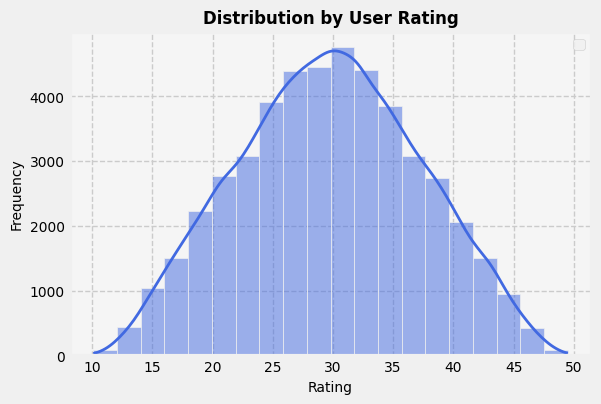

In [5]:
# Visualization - Distribution by User Rating
fig = plt.figure(figsize = (6, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
sns.histplot(data = df_vg, x = 'User Rating', bins = 20, kde = True, color = 'royalblue', line_kws = {'lw': 2})
plt.grid(linestyle = '--')
plt.title('Distribution by User Rating', fontsize = 12, fontweight = 'bold')
plt.ylabel('Frequency', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
plt.xlabel('Rating', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10)
legend = plt.legend(prop = {'size': 10}, frameon = True, loc = 'upper right')
legend.get_frame().set_linewidth(0.5);

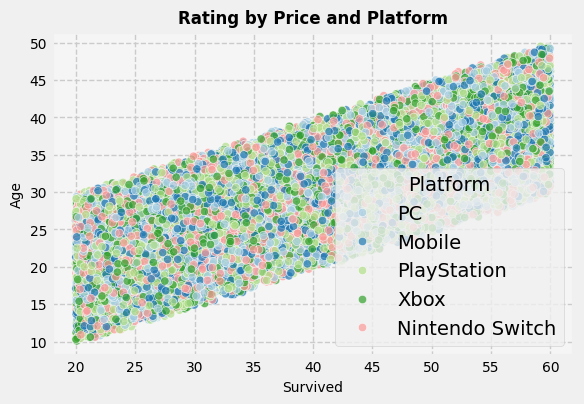

In [6]:
# Visualization - Rating label by Price and Platform
fig = plt.figure(figsize = (6, 4))
ax = fig.gca()
ax.set_facecolor('whitesmoke')
sns.scatterplot(data = df_vg, x = 'Price', y = 'User Rating', hue = 'Platform', alpha = 0.7, palette = 'Paired')
plt.grid(linestyle = '--')
plt.title('Rating by Price and Platform', fontsize = 12, fontweight = 'bold')
plt.ylabel('Age', fontsize = 10)
ax.tick_params(axis = 'y', labelsize = 10)
plt.xlabel('Survived', fontsize = 10)
ax.tick_params(axis = 'x', labelsize = 10);

#### ``Data Pre-Processing``

In [7]:
# NA-values
for col in df_vg.columns.tolist():          
    print('{} column missing values: {}'.format(col, df_vg[col].isnull().sum()))

Game Title column missing values: 0
User Rating column missing values: 0
Age Group Targeted column missing values: 0
Price column missing values: 0
Platform column missing values: 0
Requires Special Device column missing values: 0
Developer column missing values: 0
Publisher column missing values: 0
Release Year column missing values: 0
Genre column missing values: 0
Multiplayer column missing values: 0
Game Length (Hours) column missing values: 0
Graphics Quality column missing values: 0
Soundtrack Quality column missing values: 0
Story Quality column missing values: 0
User Review Text column missing values: 0
Game Mode column missing values: 0
Min Number of Players column missing values: 0


In [8]:
# Feature Selection + Target
X = df_vg.drop(['Game Title', 'Developer', 'Genre'], axis = 1)
Y = df_vg['Genre']
print(X.shape)
print(Y.shape)

(47774, 15)
(47774,)


In [9]:
# Categorical features
encoder = LabelEncoder()

categorical_columns = X.select_dtypes(include = ['object']).columns
for col in categorical_columns:
    X[col] = encoder.fit_transform(X[col].astype(str))
X.head()

,User Rating,Age Group Targeted,Price,Platform,Requires Special Device,Publisher,Release Year,Multiplayer,Game Length (Hours),Graphics Quality,Soundtrack Quality,Story Quality,User Review Text,Game Mode,Min Number of Players
0,36.4,1,41.41,2,0,4,2015,0,55.3,2,0,3,11,0,1
1,38.3,0,57.56,2,0,2,2015,1,34.6,1,3,3,11,0,3
2,26.8,3,44.93,2,1,1,2012,1,13.9,1,2,0,7,0,5
3,38.4,1,48.29,0,1,5,2015,0,41.9,2,2,1,10,1,4
4,30.1,0,55.49,3,1,3,2022,1,13.2,0,3,2,8,0,1


In [10]:
# Numerical features
sc = StandardScaler()
X[['User Rating', 'Price']] = sc.fit_transform(X[['User Rating', 'Price']])

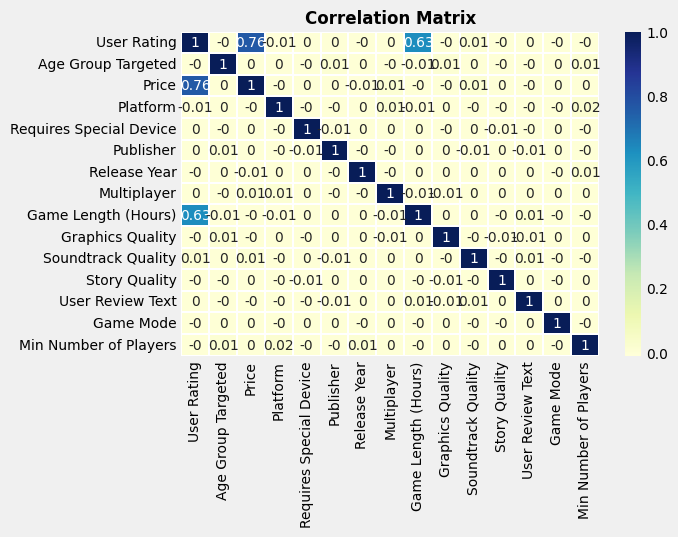

In [11]:
# Correlation Matrix
mcorr = X.corr().round(2)
fig = plt.figure(figsize = (6, 4))
sns.heatmap(mcorr, annot = True, linewidth = 0.2, cmap = 'YlGnBu', annot_kws = {'size': 10})
plt.title('Correlation Matrix', fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 10)
plt.yticks(fontsize = 10)
cbar = plt.gca().collections[0].colorbar
cbar.ax.tick_params(labelsize = 10)

In [12]:
# Train-vs-Test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 1)
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(35830, 15)
(35830,)
(11944, 15)
(11944,)


In [13]:
# Save to pickle
X_train.to_pickle('../../data/VideoGames/X_Train_VideoGames.pkl')
X_test.to_pickle('../../data/VideoGames/X_Test_VideoGames.pkl')
Y_train.to_pickle('../../data/VideoGames/Y_Train_VideoGames.pkl')
Y_test.to_pickle('../../data/VideoGames/Y_Test_VideoGames.pkl')